# Qwen1.5-MoE Smoke Test — 300 Steps

## Goal
Confirm two things only:
1. `ConflictSaturationMonitor` fires at least once within 300 steps under Run B conditions
2. The spawned sub-adapter's forward pass does not crash

PPL numbers at 300 steps are not meaningful — do not report them as results.

## Run B conditions
20% conflict ratio: 80% Python (code) examples, 20% Medical examples, interleaved.

## Jaccard diagnostic results
- Chosen pair: **Python vs Medical** (Option A)
- TARGET_LAYER: **0** (highest top-K Jaccard = 0.154)
- TARGET_EXPERT: **5** (highest conflict score = 0.0236)

## What changed from the OLMoE implementation
- `model_dim = 2048` — same as OLMoE, no change needed
- Wrapper class renamed `HierarchicalQwenExperts`
- Qwen has a **shared expert** (`mlp.shared_expert`) that fires on every token — left frozen, NOT wrapped
- We only patch `mlp.experts` (the 60 routing experts) — the MoE block adds the shared expert output after our wrapper returns, so it is transparent to us
- Domain pair: Python/Medical instead of Math/Creative
- No AlignDevicesHook needed (single A100)
- `ConflictSaturationMonitor`: **zero changes** — reads only LoRA gradients
- `HierarchicalExpert` (sub-adapter): **zero changes** — architecture-agnostic

## Cell 1 — Load Model

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import gc
import json
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "Qwen/Qwen1.5-MoE-A2.7B"

gc.collect()
torch.cuda.empty_cache()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
)
model.gradient_checkpointing_disable()  # required with custom wrappers
model.config.use_cache = False

print(f"Model loaded. VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/919 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/387 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/144 [00:00<?, ?B/s]

Model loaded. VRAM: 28.65 GB


## Cell 2 — Load Experiment Config from Jaccard Diagnostic

In [2]:
CONFIG_PATH = "qwen_experiment_config.json"

try:
    with open(CONFIG_PATH) as f:
        cfg = json.load(f)
    TARGET_LAYER  = cfg["target_layer"]
    TARGET_EXPERT = cfg["target_expert"]
    MODEL_DIM     = cfg["model_dim"]
    print("Config loaded from Jaccard diagnostic.")
except FileNotFoundError:
    print("Config not found — using fallback defaults from Jaccard output.")
    cfg = {
        "primary_dataset":  "openai/openai_humaneval",
        "primary_col":      "prompt",
        "primary_config":   None,
        "conflict_dataset": "qiaojin/PubMedQA",
        "conflict_col":     "question",
        "conflict_config":  "pqa_labeled",
        "domain_names":     ["code", "medical"],
    }
    TARGET_LAYER  = 0   # from Jaccard: highest top-K Jaccard = 0.154
    TARGET_EXPERT = 5   # from Jaccard: highest conflict score = 0.0236
    MODEL_DIM     = 2048

print(f"  TARGET_LAYER  = {TARGET_LAYER}")
print(f"  TARGET_EXPERT = {TARGET_EXPERT}")
print(f"  MODEL_DIM     = {MODEL_DIM}")

Config not found — using fallback defaults from Jaccard output.
  TARGET_LAYER  = 0
  TARGET_EXPERT = 5
  MODEL_DIM     = 2048


## Cell 3 — HierarchicalExpert (Sub-Adapter)

**Identical to the OLMoE implementation.** Architecture-agnostic — operates on
`model_dim`-dimensional hidden states only. `model_dim = 2048` for both OLMoE and Qwen.

In [3]:
class HierarchicalExpert(nn.Module):
    """
    LoRA sub-adapter. Computes: (x @ A.T @ B.T) * scaling
    B=0 at init → zero output → no loss spike on insertion.
    Identical to OLMoE implementation — architecture-agnostic.
    """
    def __init__(self, in_features, out_features, base_rank=16, lora_alpha=32):
        super().__init__()
        self.scaling = lora_alpha / base_rank
        self.A = nn.Parameter(torch.randn(base_rank, in_features) * 0.01)
        self.B = nn.Parameter(torch.zeros(out_features, base_rank))  # B=0 always

    def forward(self, x):
        A = self.A.to(x.dtype)
        B = self.B.to(x.dtype)
        return (x @ A.t() @ B.t()) * self.scaling


print("HierarchicalExpert defined. (identical to OLMoE implementation)")

HierarchicalExpert defined. (identical to OLMoE implementation)


## Cell 4 — ConflictSaturationMonitor

**Zero changes from OLMoE.** Reads only LoRA weight norms and domain-separated
loss EMAs — no model-specific code.

In [4]:
class ConflictSaturationMonitor:
    """
    Fires when BOTH hold for `window` consecutive steps:
      1. Plateau: OLS slope of rank importance < tau_plateau
      2. Conflict: |ema_medical - ema_code| > delta_threshold

    Zero changes from OLMoE implementation.
    """
    def __init__(self, tau_plateau=1e-4, delta_threshold=1.0, window=15, beta=0.9):
        self.tau_plateau     = tau_plateau
        self.delta_threshold = delta_threshold
        self.window          = window
        self.beta            = beta

        self._ri_history      = []
        self._ema_code        = None
        self._ema_medical     = None
        self._plateau_window  = []
        self._conflict_window = []

    def update(self, lora_A, lora_B, loss_val, domain, primary_domain="code"):
        b = self.beta
        if domain == primary_domain:
            self._ema_code = (loss_val if self._ema_code is None
                              else b * self._ema_code + (1-b) * loss_val)
        else:
            self._ema_medical = (loss_val if self._ema_medical is None
                                 else b * self._ema_medical + (1-b) * loss_val)

        with torch.no_grad():
            col_norms = lora_B.detach().float().norm(dim=0)
            row_norms = lora_A.detach().float().norm(dim=1)
            ri = (col_norms * row_norms).mean().item()
        self._ri_history.append(ri)

        if len(self._ri_history) < self.window:
            return False

        recent = self._ri_history[-self.window:]
        x = torch.arange(len(recent), dtype=torch.float32)
        y = torch.tensor(recent,      dtype=torch.float32)
        slope = ((x*y).mean() - x.mean()*y.mean()) / (x.var(unbiased=False) + 1e-12)
        plateau = abs(slope.item()) < self.tau_plateau

        conflict = (self._ema_code is not None and self._ema_medical is not None and
                    abs(self._ema_medical - self._ema_code) > self.delta_threshold)

        self._plateau_window.append(plateau)
        self._conflict_window.append(conflict)
        if len(self._plateau_window) > self.window:
            self._plateau_window.pop(0)
            self._conflict_window.pop(0)

        if (len(self._plateau_window) == self.window
                and all(self._plateau_window)
                and all(self._conflict_window)):
            self._plateau_window.clear()
            self._conflict_window.clear()
            return True
        return False

    def reset_after_spawn(self):
        self._ri_history.clear()
        self._plateau_window.clear()
        self._conflict_window.clear()


print("ConflictSaturationMonitor defined. (identical to OLMoE implementation)")

ConflictSaturationMonitor defined. (identical to OLMoE implementation)


## Cell 5 — HierarchicalQwenExperts Wrapper

**What changed from `HierarchicalOLMoEExperts`:**
- Class renamed `HierarchicalQwenExperts`
- `num_experts = 60` (Qwen routing experts only — shared expert excluded)
- `lora_dim = out_f = 2048` — same as OLMoE, no numerical change

**What did NOT change:**
- Calling convention: `forward(hidden_states, top_k_index, top_k_weights)` — identical
- Packed tensor layout: `down_proj [60, 2048, 1408]` — same 3D structure as OLMoE
- Spawn mechanism, gate vectors, SVD init — unchanged
- Zero-output guarantee (B=0) — unchanged

**Shared expert note:**
We only replace `mlp.experts`. After our wrapper returns, `Qwen2MoeSparseMoeBlock.forward()`
adds the shared expert output on its own. That path is completely independent — we never
see it, and it remains frozen.

In [5]:
class HierarchicalQwenExperts(nn.Module):
    """
    Drop-in replacement for Qwen2MoeExperts (the routing expert container).

    Qwen2MoeSparseMoeBlock calls:
        expert_output = self.experts(hidden_states, top_k_index, top_k_weights)
        shared_output = torch.sigmoid(self.shared_expert_gate(hidden_states)) * self.shared_expert(hidden_states)
        output = expert_output + shared_output

    We intercept only the expert_output call. shared_expert is untouched.

    LoRA correction lives in model_dim → model_dim space (2048 → 2048).
    Using ffn_dim (1408) would be the same bug as the Phi→OLMoE port.

    Changes from HierarchicalOLMoEExperts:
      - Class name
      - num_experts = 60 (routing only)
      - lora_dim = 2048 (numerically identical to OLMoE)
    """

    def __init__(self, original_experts, base_rank=16, lora_alpha=32):
        super().__init__()
        self.original = original_experts

        for p in self.original.parameters():
            p.requires_grad = False

        # down_proj: [num_experts, out_f, in_f] = [60, 2048, 1408]
        # out_f = model_dim = 2048 — this is the LoRA dimension
        # in_f  = ffn_dim   = 1408 — do NOT use this for LoRA
        self.num_experts, self.out_f, self.in_f = self.original.down_proj.shape
        self.lora_dim = self.out_f   # = 2048 = model_dim
        self.dtype    = self.original.down_proj.dtype
        dev = self.original.down_proj.device

        # Base LoRA per routing expert — always active, no gate
        self.base_loras = nn.ModuleList([
            HierarchicalExpert(
                in_features=self.lora_dim,
                out_features=self.lora_dim,
                base_rank=base_rank,
                lora_alpha=lora_alpha,
            ).to(dev).to(self.dtype)
            for _ in range(self.num_experts)
        ])

        # Spawned adapters — plain Python lists, added to optimizer on spawn
        self.spawn_loras = [[] for _ in range(self.num_experts)]
        self.spawn_gates = [[] for _ in range(self.num_experts)]

    @property
    def device(self):
        return self.original.down_proj.device

    def forward(self, hidden_states, top_k_index, top_k_weights):
        """
        hidden_states: [T, model_dim=2048]
        top_k_index:   [T, 4]  int64
        top_k_weights: [T, 4]  float

        Calling convention identical to Qwen2MoeExperts.forward().
        Returns routing expert output only — shared expert handled by MoE block.
        """
        # Step 1: original routing expert computation
        original_out = self.original(hidden_states, top_k_index, top_k_weights)

        # Step 2: add base LoRA correction for each activated routing expert
        correction = torch.zeros_like(original_out)

        with torch.no_grad():
            expert_mask = F.one_hot(top_k_index, num_classes=self.num_experts)  # [T, 4, 60]
            expert_mask = expert_mask.permute(2, 1, 0)  # [60, 4, T]
            expert_hit  = torch.greater(expert_mask.sum(dim=(-1, -2)), 0).nonzero()

        for expert_idx_tensor in expert_hit:
            k = expert_idx_tensor[0].item()
            top_k_pos, token_idx = torch.where(expert_mask[k])
            tokens = hidden_states[token_idx]  # [n_selected, model_dim]

            # Base LoRA correction
            base_corr = self.base_loras[k](tokens)  # [n_selected, model_dim]
            weights   = top_k_weights[token_idx, top_k_pos, None]  # [n_selected, 1]
            base_corr = base_corr * weights
            correction.index_add_(0, token_idx, base_corr.to(correction.dtype))

            # Spawned sub-adapter corrections
            for gate_vec, lora_module in zip(self.spawn_gates[k], self.spawn_loras[k]):
                gate_score = F.relu(tokens @ gate_vec.to(tokens.dtype))  # [n_selected]
                sub_corr   = lora_module(tokens) * gate_score.unsqueeze(-1)
                sub_corr   = sub_corr * weights
                correction.index_add_(0, token_idx, sub_corr.to(correction.dtype))

        return original_out + correction

    def spawn(self, expert_id, rank=8, weight_grad=None):
        """
        Spawn a new ReLU-gated sub-adapter for routing expert `expert_id`.
        Returns new parameters to add to the optimizer.
        B=0 guarantees zero output at spawn time.
        """
        dev   = self.device
        dtype = self.dtype

        gate = nn.Parameter(
            torch.randn(self.lora_dim, device=dev, dtype=dtype) * 1e-3
        )
        lora_module = HierarchicalExpert(
            in_features=self.lora_dim,
            out_features=self.lora_dim,
            base_rank=rank,
        ).to(dev).to(dtype)

        if weight_grad is not None:
            try:
                g  = weight_grad.float().cpu()
                g  = g.clamp(-1e4, 1e4)
                _, _, Vt = torch.linalg.svd(g, full_matrices=False)
                lora_module.A.data.copy_(Vt[:rank].to(dtype).to(dev))
                print(f"    [spawn] Expert {expert_id}: SVD init successful")
            except Exception as e:
                print(f"    [spawn] Expert {expert_id}: SVD failed ({e}), using random init")

        self.spawn_gates[expert_id].append(gate)
        self.spawn_loras[expert_id].append(lora_module)

        print(f"  ✅ Spawned sub-adapter #{len(self.spawn_loras[expert_id])} "
              f"for Routing Expert {expert_id}")
        return [gate] + list(lora_module.parameters())


print("HierarchicalQwenExperts defined.")

HierarchicalQwenExperts defined.


## Cell 6 — Patch the Target Layer

Replace `model.model.layers[TARGET_LAYER].mlp.experts` with the wrapper.

- `mlp.shared_expert` and `mlp.shared_expert_gate` are NOT touched — they remain
  frozen inside `Qwen2MoeSparseMoeBlock` and fire independently on every token.
- No AlignDevicesHook transfer needed (single A100).

In [6]:
# Freeze all model parameters
for p in model.parameters():
    p.requires_grad = False

# Idempotent unwrap: if already patched, restore original first
current = model.model.layers[TARGET_LAYER].mlp.experts
if isinstance(current, HierarchicalQwenExperts):
    print("Already patched — unwrapping first.")
    model.model.layers[TARGET_LAYER].mlp.experts = current.original

original_experts = model.model.layers[TARGET_LAYER].mlp.experts

# Inspect dimensions before patching
num_experts, out_f, in_f = original_experts.down_proj.shape
print(f"Layer {TARGET_LAYER} | num_routing_experts={num_experts} | model_dim={out_f} | ffn_dim={in_f}")
assert out_f == MODEL_DIM, f"Expected model_dim={MODEL_DIM}, got {out_f}"

# Confirm shared expert is present and untouched
moe_block = model.model.layers[TARGET_LAYER].mlp
assert hasattr(moe_block, 'shared_expert'), "shared_expert not found — check model structure"
print(f"Shared expert confirmed: {type(moe_block.shared_expert).__name__} (frozen, not wrapped)")

# Apply patch
hier = HierarchicalQwenExperts(original_experts, base_rank=16, lora_alpha=32)
model.model.layers[TARGET_LAYER].mlp.experts = hier
print(f"Patched mlp.experts at layer {TARGET_LAYER}.")

# Smoke-test: forward pass — output should be identical (B=0)
with torch.no_grad():
    T = 8
    hs  = torch.randn(T, out_f, device=hier.device, dtype=hier.dtype)
    idx = torch.randint(0, num_experts, (T, 4), device=hier.device)
    wts = torch.ones(T, 4, device=hier.device, dtype=hier.dtype) / 4

    orig_out    = original_experts(hs, idx, wts)
    patched_out = hier(hs, idx, wts)
    diff = (orig_out - patched_out).abs().max().item()

print(f"\nPatch smoke-test ‖orig − patched‖_max = {diff:.8f}  (should be ~0.0)")
assert diff < 1e-3, "Output mismatch — check wrapper forward()"

trainable = [p for p in hier.parameters() if p.requires_grad]
print(f"Trainable params in wrapper: {sum(p.numel() for p in trainable):,}")
print(f"(shared_expert params are frozen and outside wrapper — verified above)")

Layer 0 | num_routing_experts=60 | model_dim=2048 | ffn_dim=1408
Shared expert confirmed: Qwen2MoeMLP (frozen, not wrapped)
Patched mlp.experts at layer 0.

Patch smoke-test ‖orig − patched‖_max = 0.00000000  (should be ~0.0)
Trainable params in wrapper: 3,932,160
(shared_expert params are frozen and outside wrapper — verified above)


## Cell 7 — Build Run B Dataset (20% Conflict)

80% Python (code), 20% Medical, interleaved so both domains appear early.
Uses Python vs Medical pair selected by Jaccard diagnostic.

In [7]:
from datasets import load_dataset

PRIMARY_DATASET  = cfg.get("primary_dataset",  "openai/openai_humaneval")
PRIMARY_COL      = cfg.get("primary_col",       "prompt")
PRIMARY_CONFIG   = cfg.get("primary_config",    None)
CONFLICT_DATASET = cfg.get("conflict_dataset", "qiaojin/PubMedQA")
CONFLICT_COL     = cfg.get("conflict_col",      "question")
CONFLICT_CONFIG  = cfg.get("conflict_config",   "pqa_labeled")
DOMAIN_NAMES     = cfg.get("domain_names",      ["code", "medical"])

N_PRIMARY  = 50
N_CONFLICT = 13   # ~20% of total
MAX_LEN    = 128

def load_texts(dataset_name, text_col, config_name=None, n=60):
    kwargs    = {"name": config_name} if config_name else {}
    ds_dict   = load_dataset(dataset_name, **kwargs)
    available = list(ds_dict.keys())
    split     = "train" if "train" in available else ("test" if "test" in available else available[0])
    ds = ds_dict[split]
    return [str(ex[text_col]) for ex in ds.select(range(min(n, len(ds))))]

print("Loading datasets...")
primary_texts  = load_texts(PRIMARY_DATASET,  PRIMARY_COL,  PRIMARY_CONFIG,  n=N_PRIMARY)
conflict_texts = load_texts(CONFLICT_DATASET, CONFLICT_COL, CONFLICT_CONFIG, n=N_CONFLICT)

# Interleave: 4 primary then 1 conflict, repeat
texts, domains = [], []
pi = ci = 0
while pi < len(primary_texts) or ci < len(conflict_texts):
    for _ in range(4):
        if pi < len(primary_texts):
            texts.append(primary_texts[pi]);  domains.append(DOMAIN_NAMES[0]);  pi += 1
    if ci < len(conflict_texts):
        texts.append(conflict_texts[ci]);  domains.append(DOMAIN_NAMES[1]);  ci += 1

encodings = tokenizer(
    texts,
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="pt",
).to(model.device)

primary_count  = domains.count(DOMAIN_NAMES[0])
conflict_count = domains.count(DOMAIN_NAMES[1])
print(f"Dataset: {primary_count} {DOMAIN_NAMES[0]} + {conflict_count} {DOMAIN_NAMES[1]} = {len(texts)} total")
print(f"Conflict ratio: {conflict_count/len(texts)*100:.1f}%  (target ~20%)")

Loading datasets...


README.md: 0.00B [00:00, ?B/s]

openai_humaneval/test-00000-of-00001.par(…):   0%|          | 0.00/83.9k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/164 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

pqa_labeled/train-00000-of-00001.parquet:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset: 50 code + 13 medical = 63 total
Conflict ratio: 20.6%  (target ~20%)


## Cell 8 — Training Loop (300 Steps)

Tracks three check flags:
- `check_trigger`: monitor fired at least once
- `check_no_crash`: spawned adapter's forward pass completed without error
- `check_zero_spawn`: |ΔLoss| < 0.01 immediately after spawn

Logs every 50 steps: loss, domain, EMA states, spawn count.

In [8]:
N_STEPS = 300
LR      = 2e-5

monitor = ConflictSaturationMonitor(
    tau_plateau=1e-4,
    delta_threshold=1.0,
    window=15,
    beta=0.9,
)

optimizer = torch.optim.AdamW(
    [p for p in hier.parameters() if p.requires_grad],
    lr=LR,
)

check_trigger    = False
check_no_crash   = True
check_zero_spawn = None

loss_log    = []
spawn_steps = []
loss_before_spawn = None

print(f"Running {N_STEPS} steps — Layer {TARGET_LAYER}, Expert {TARGET_EXPERT} (Python/Medical 80/20)")
print(f"{'Step':>5} {'Domain':>8} {'Loss':>8} {'EMA_code':>10} {'EMA_med':>10} {'Spawns':>7}")
print("-" * 55)

for step in range(N_STEPS):
    idx       = step % len(texts)
    domain    = domains[idx]
    input_ids = encodings["input_ids"][idx].unsqueeze(0)
    labels    = input_ids.clone()
    labels[:, :-1] = input_ids[:, 1:]
    labels[:, -1]  = -100

    optimizer.zero_grad()

    try:
        loss = model(input_ids=input_ids, labels=labels).loss
    except Exception as e:
        print(f"\n❌ Forward pass crashed at step {step}: {e}")
        check_no_crash = False
        break

    loss_log.append(loss.item())
    loss.backward()
    optimizer.step()

    lora = hier.base_loras[TARGET_EXPERT]

    triggered = monitor.update(
        lora_A=lora.A.data,
        lora_B=lora.B.data,
        loss_val=loss.item(),
        domain=domain,
        primary_domain=DOMAIN_NAMES[0],
    )

    if triggered and len(hier.spawn_loras[TARGET_EXPERT]) < 10:
        check_trigger     = True
        loss_before_spawn = loss.item()

        grad_A = lora.A.grad
        grad_B = lora.B.grad
        weight_grad = (grad_B.detach().float() @ grad_A.detach().float()
                       if grad_A is not None and grad_B is not None else None)

        new_params = hier.spawn(TARGET_EXPERT, rank=8, weight_grad=weight_grad)
        optimizer.add_param_group({"params": new_params, "lr": LR})
        spawn_steps.append(step)
        monitor.reset_after_spawn()

        try:
            with torch.no_grad():
                loss_after = model(input_ids=input_ids, labels=labels).loss.item()
            delta = abs(loss_after - loss_before_spawn)
            check_zero_spawn = delta
            print(f"    |ΔLoss| at spawn = {delta:.8f}  (expect ~0.0)")
        except Exception as e:
            print(f"    ❌ Forward pass after spawn crashed: {e}")
            check_no_crash = False

    if (step + 1) % 50 == 0 or triggered:
        ema_c = f"{monitor._ema_code:.3f}"    if monitor._ema_code    is not None else "  N/A"
        ema_m = f"{monitor._ema_medical:.3f}" if monitor._ema_medical is not None else "  N/A"
        n_spawns = len(hier.spawn_loras[TARGET_EXPERT])
        print(f"{step+1:>5} {domain:>8} {loss.item():>8.3f} {ema_c:>10} {ema_m:>10} {n_spawns:>7}")

print("\nTraining complete.")

Running 300 steps — Layer 0, Expert 5 (Python/Medical 80/20)
 Step   Domain     Loss   EMA_code    EMA_med  Spawns
-------------------------------------------------------
   50  medical   10.491     14.990     13.135       0
  100     code   10.120      9.783      9.651       0
    [spawn] Expert 5: SVD init successful
  ✅ Spawned sub-adapter #1 for Routing Expert 5
    |ΔLoss| at spawn = 0.01175022  (expect ~0.0)
  116     code   13.273     11.731      8.518       1
    [spawn] Expert 5: SVD init successful
  ✅ Spawned sub-adapter #2 for Routing Expert 5
    |ΔLoss| at spawn = 0.05864382  (expect ~0.0)
  145     code    7.177      9.525      6.596       2
  150     code    9.848      9.485      6.372       2
    [spawn] Expert 5: SVD init successful
  ✅ Spawned sub-adapter #3 for Routing Expert 5
    |ΔLoss| at spawn = 0.00708199  (expect ~0.0)
  174     code   13.762     10.447      5.132       3
  200     code   10.366     10.139      4.052       3
    [spawn] Expert 5: SVD init suc

## Cell 9 — Results Report

QWEN SMOKE TEST RESULTS

✅ Check 1 — Trigger fired: YES
   Spawn steps: [115, 144, 173, 206, 235, 264, 293]
   Total spawns: 7

✅ Check 2 — Forward pass after spawn: NO CRASH
   ⚠️  |ΔLoss| at spawn = 0.02734089  (threshold: 0.01)

NOTE: PPL numbers at 300 steps are not meaningful — not reported.
      Total steps run: 300
      Final loss: 11.4354


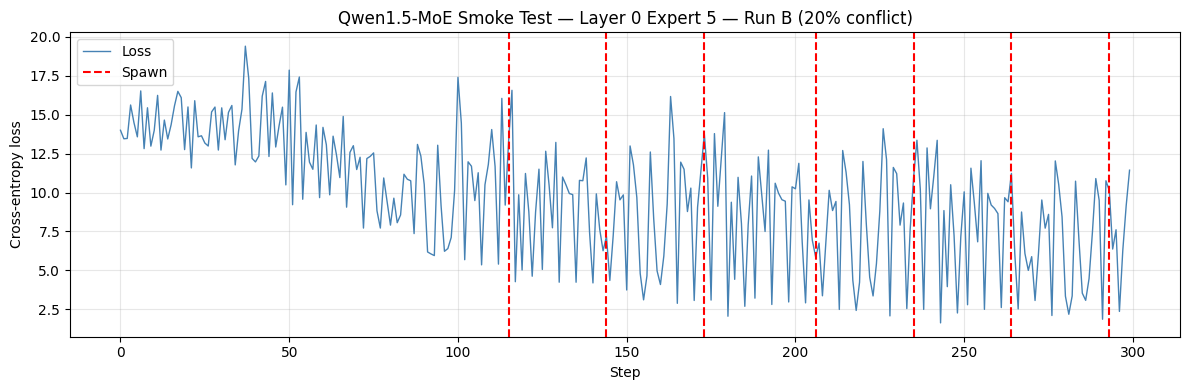

Saved: qwen_smoke_test_loss.png


In [9]:
import matplotlib.pyplot as plt

print("=" * 55)
print("QWEN SMOKE TEST RESULTS")
print("=" * 55)
print()

if check_trigger:
    print(f"✅ Check 1 — Trigger fired: YES")
    print(f"   Spawn steps: {spawn_steps}")
    print(f"   Total spawns: {len(spawn_steps)}")
else:
    print(f"❌ Check 1 — Trigger fired: NO")
    print(f"   Monitor did not fire in {N_STEPS} steps.")
    print(f"   EMA_code at end:    {monitor._ema_code}")
    print(f"   EMA_medical at end: {monitor._ema_medical}")
    if monitor._ema_code and monitor._ema_medical:
        divergence = abs(monitor._ema_medical - monitor._ema_code)
        print(f"   |EMA divergence|: {divergence:.4f} (threshold: {monitor.delta_threshold})")
        print(f"   → Run Cell 10 diagnostics")

print()

if check_no_crash and check_trigger:
    print(f"✅ Check 2 — Forward pass after spawn: NO CRASH")
    if check_zero_spawn is not None:
        status = "✅" if check_zero_spawn < 0.01 else "⚠️ "
        print(f"   {status} |ΔLoss| at spawn = {check_zero_spawn:.8f}  (threshold: 0.01)")
elif not check_trigger:
    print(f"⏭️  Check 2 — Skipped (trigger never fired)")
else:
    print(f"❌ Check 2 — Forward pass after spawn: CRASHED")

print()
print("NOTE: PPL numbers at 300 steps are not meaningful — not reported.")
print(f"      Total steps run: {len(loss_log)}")
if loss_log:
    print(f"      Final loss: {loss_log[-1]:.4f}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(loss_log, color='steelblue', linewidth=1, label='Loss')
for s in spawn_steps:
    ax.axvline(x=s, color='red', linestyle='--', linewidth=1.5,
               label='Spawn' if s == spawn_steps[0] else None)
ax.set_xlabel('Step')
ax.set_ylabel('Cross-entropy loss')
ax.set_title(f'Qwen1.5-MoE Smoke Test — Layer {TARGET_LAYER} Expert {TARGET_EXPERT} — Run B (20% conflict)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('qwen_smoke_test_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: qwen_smoke_test_loss.png")

## Cell 10 — If Trigger Did Not Fire: Diagnostics

Run only if Check 1 failed. Logs both monitor conditions every step
to identify which one is not being met.

**Common fixes:**
- `|EMA divergence|` never exceeds threshold → lower `delta_threshold` to 0.5
- Slope never plateaus → lower `tau_plateau` to 1e-3
- Both conditions almost met → increase N_STEPS to 500

In [10]:
if check_trigger:
    print("Trigger fired — no diagnostics needed. Skip this cell.")
else:
    print("Trigger did not fire. Running 100-step diagnostic trace...")
    print(f"{'Step':>5} {'Domain':>8} {'Loss':>8} {'RI_slope':>10} {'Plateau?':>9} {'|ΔEMA|':>8} {'Conflict?':>10}")
    print("-" * 70)

    # Re-patch fresh
    current = model.model.layers[TARGET_LAYER].mlp.experts
    if isinstance(current, HierarchicalQwenExperts):
        orig = current.original
        model.model.layers[TARGET_LAYER].mlp.experts = orig
    else:
        orig = current

    hier2 = HierarchicalQwenExperts(orig, base_rank=16, lora_alpha=32)
    model.model.layers[TARGET_LAYER].mlp.experts = hier2

    diag_monitor = ConflictSaturationMonitor(tau_plateau=1e-4, delta_threshold=1.0, window=15)
    diag_opt = torch.optim.AdamW([p for p in hier2.parameters() if p.requires_grad], lr=LR)

    for step in range(100):
        idx2       = step % len(texts)
        domain2    = domains[idx2]
        input_ids2 = encodings["input_ids"][idx2].unsqueeze(0)
        labels2    = input_ids2.clone()
        labels2[:, :-1] = input_ids2[:, 1:]
        labels2[:, -1]  = -100

        diag_opt.zero_grad()
        loss2 = model(input_ids=input_ids2, labels=labels2).loss
        loss2.backward()
        diag_opt.step()

        lora2 = hier2.base_loras[TARGET_EXPERT]
        diag_monitor.update(lora2.A.data, lora2.B.data, loss2.item(), domain2)

        if len(diag_monitor._ri_history) >= 15:
            recent = diag_monitor._ri_history[-15:]
            x = torch.arange(15, dtype=torch.float32)
            y = torch.tensor(recent, dtype=torch.float32)
            slope = ((x*y).mean() - x.mean()*y.mean()) / (x.var(unbiased=False) + 1e-12)
            plateau   = abs(slope.item()) < 1e-4
            slope_val = slope.item()
        else:
            slope_val, plateau = float('nan'), False

        ec = diag_monitor._ema_code
        em = diag_monitor._ema_medical
        delta_ema = abs(em - ec) if ec is not None and em is not None else float('nan')
        conflict  = delta_ema > 1.0 if not (delta_ema != delta_ema) else False

        if (step + 1) % 10 == 0:
            print(f"{step+1:>5} {domain2:>8} {loss2.item():>8.3f} "
                  f"{slope_val:>10.2e} {'YES' if plateau else 'NO':>9} "
                  f"{delta_ema:>8.3f} {'YES' if conflict else 'NO':>10}")

    print()
    print("Diagnosis:")
    print(f"  Final |ΔEMA|: {delta_ema:.4f} (need > 1.0 for conflict)")
    print(f"  Final slope:  {slope_val:.2e} (need < 1e-4 for plateau)")
    if delta_ema < 1.0:
        print("  → Lower delta_threshold to 0.5 in ConflictSaturationMonitor")
    if not (slope_val != slope_val) and abs(slope_val) >= 1e-4:
        print("  → Lower tau_plateau to 1e-3 in ConflictSaturationMonitor")

Trigger fired — no diagnostics needed. Skip this cell.
